In [47]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="fastai")

In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score, precision_score, f1_score

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from autogluon.tabular import TabularPredictor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, average_precision_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#2196F3', '#F44336']

os.makedirs('models', exist_ok=True)
print('All libraries loaded successfully.')


All libraries loaded successfully.


In [3]:
# 1. Load datasets
train_data = pd.read_csv('Training.csv')
test_data = pd.read_csv('Testing.csv')

In [4]:
train_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
train_data.shape

(2460, 9)

In [6]:
test_data.shape

(308, 9)

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   int64  
 2   BloodPressure             2460 non-null   int64  
 3   SkinThickness             2460 non-null   int64  
 4   Insulin                   2460 non-null   int64  
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 173.1 KB


In [8]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               308 non-null    int64  
 1   Glucose                   308 non-null    int64  
 2   BloodPressure             308 non-null    int64  
 3   SkinThickness             308 non-null    int64  
 4   Insulin                   308 non-null    int64  
 5   BMI                       308 non-null    float64
 6   DiabetesPedigreeFunction  308 non-null    float64
 7   Age                       308 non-null    int64  
 8   Outcome                   308 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 21.8 KB


In [9]:
train_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000
mean,3.817480,121.602033,68.915041,20.531301,80.119919,31.990447,0.491440,32.821951,0.390244
std,3.296458,31.789270,19.082655,15.716901,116.765807,7.802569,0.363917,11.251208,0.487904
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.100000,0.251750,24.000000,0.000000
50%,3.000000,117.000000,70.000000,23.000000,36.000000,32.100000,0.381000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.500000,0.647000,39.000000,1.000000
max,17.000000,197.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
test_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,3.863636,119.983766,69.503247,20.694805,77.724026,31.865909,0.445042,33.730519,0.301948
std,3.381437,31.186260,19.555067,16.298250,106.528025,7.427594,0.297660,12.208374,0.459850
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.085000,21.000000,0.000000
25%,1.000000,97.750000,62.000000,0.000000,0.000000,27.400000,0.228250,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,17.000000,32.000000,0.348000,29.000000,0.000000
75%,6.000000,136.000000,80.000000,32.000000,127.750000,36.425000,0.600000,42.000000,1.000000
max,13.000000,199.000000,114.000000,99.000000,600.000000,57.300000,1.699000,70.000000,1.000000


In [11]:
train_data.duplicated().sum()

2000

In [12]:
test_data.duplicated().sum()

0

In [13]:
# 2. Preprocessing: Handling the zeros in both sets
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
train_data[cols_with_zeros] = train_data[cols_with_zeros].replace(0, np.nan)
test_data[cols_with_zeros] = test_data[cols_with_zeros].replace(0, np.nan)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Correlations
correlations = train_data.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)

In [15]:
# Train AutoGluon — optimising for Recall (clinical priority: catch every diabetic)
# path= is REQUIRED so the Streamlit app can load the predictor from a fixed location
predictor = TabularPredictor(
    label='Outcome',
    eval_metric='recall',
    path='AutogluonModels/ag_model'
).fit(
    train_data,
    presets='best_quality',
    time_limit=600
)
print('Training complete. Model saved to AutogluonModels/ag_model/')


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:54:22 PST 2026; root:xnu-12377.81.4~5/RELEASE_ARM64_T6030
CPU Count:          12
Memory Avail:       4.33 GB / 18.00 GB (24.1%)
Disk Space Avail:   123.97 GB / 460.43 GB (26.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then

(_ray_fit pid=65277) [1000]	valid_set's binary_logloss: 0.316267	valid_set's recall: 0.850467


(_dystack pid=65118) 	0.9519	 = Validation score   (recall)
(_dystack pid=65118) 	2.95s	 = Training   runtime
(_dystack pid=65118) 	0.22s	 = Validation runtime
(_dystack pid=65118) Fitting model: NeuralNetTorch_r22_BAG_L1 ... Training model for up to 44.77s of the 94.15s of remaining time.
(_dystack pid=65118) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.02%)
(_ray_fit pid=65256) No improvement since epoch 22: early stopping [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_dystack pid=65118) 	0.9965	 = Validation score   (recall)
(_dystack pid=65118) 	6.06s	 = Training   runtime
(_dystack pid=65118) 	0.08s	 = Validation runtime
(_dystack pid=65118) Fitting model: XGBoost_r33_BAG_L1 ... Training model for up to 37

Training complete. Model saved to AutogluonModels/ag_model/


Computing feature importance via permutation shuffling for 8 features using 308 rows with 5 shuffle sets...
	2.73s	= Expected runtime (0.55s per shuffle set)
	0.54s	= Actual runtime (Completed 5 of 5 shuffle sets)


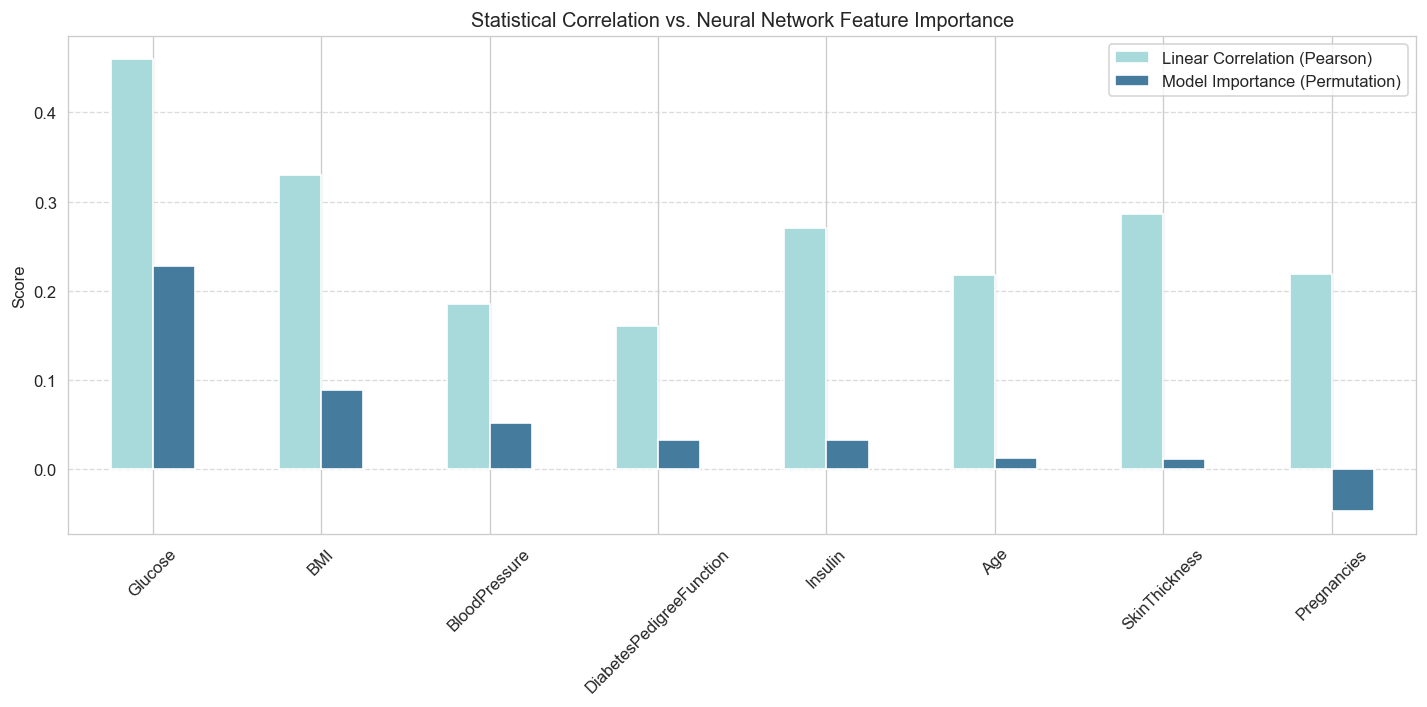

In [28]:
# 2. Get Model Feature Importance
# Ensure 'predictor' and 'test_data' are defined from your previous steps
importance = predictor.feature_importance(test_data, model='NeuralNetFastAI_r4_BAG_L1')
model_importance = importance['importance']

# 3. Combine into one DataFrame for plotting
df_compare = pd.DataFrame({
    'Linear Correlation': correlations,
    'Model Importance': model_importance
}).sort_values(by='Model Importance', ascending=False)

# 4. Plot Side-by-Side
fig, ax1 = plt.subplots(figsize=(12, 6))

df_compare.plot(kind='bar', ax=ax1, color=['#A8DADC', '#457B9D'])
plt.title('Statistical Correlation vs. Neural Network Feature Importance')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(["Linear Correlation (Pearson)", "Model Importance (Permutation)"])
plt.tight_layout()
plt.show()

In [29]:
#2. Comprehensive Leaderboard
# This shows all models ranked by Recall, but including other metrics
print("\n--- Multi-Metric Leaderboard ---")
metrics = ['accuracy', 'precision', 'f1', 'balanced_accuracy']
lb = predictor.leaderboard(test_data, extra_metrics=metrics)
print(lb)


--- Multi-Metric Leaderboard ---
                           model  score_test  accuracy  precision        f1  \
0    NeuralNetFastAI_r187_BAG_L1    1.000000  0.321429   0.307947  0.470886   
1    NeuralNetFastAI_r143_BAG_L1    1.000000  0.487013   0.370518  0.540698   
2    NeuralNetFastAI_r156_BAG_L1    0.881720  0.409091   0.324111  0.473988   
3     NeuralNetFastAI_r65_BAG_L1    0.860215  0.418831   0.325203  0.471976   
4      NeuralNetFastAI_r4_BAG_L1    0.817204  0.782468   0.603175  0.694064   
..                           ...         ...       ...        ...       ...   
106     RandomForest_r195_BAG_L1    0.580645  0.762987   0.613636  0.596685   
107           XGBoost_r34_BAG_L1    0.580645  0.788961   0.675000  0.624277   
108         LightGBM_r161_BAG_L1    0.569892  0.792208   0.688312  0.623529   
109         LightGBM_r121_BAG_L1    0.548387  0.788961   0.689189  0.610778   
110         LightGBMLarge_BAG_L1    0.526882  0.756494   0.612500  0.566474   

     balanced_acc

In [30]:
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, confusion_matrix
# 1. LOCK IN YOUR CHOSEN MODEL
# This is the 'NeuralNetFastAI_r4_BAG_L1' you found on the leaderboard
specific_model = 'NeuralNetFastAI_r4_BAG_L1'

In [31]:
# 2. GET PROBABILITIES FROM THIS SPECIFIC MODEL
# Note: We must specify 'model=specific_model' here
probs = predictor.predict_proba(test_data, model=specific_model).iloc[:, 1]

In [32]:
# 3. APPLY YOUR CUSTOM THRESHOLD
# 0.30 is your sweet spot for balancing Recall and Accuracy
threshold = 0.50
custom_preds = (probs >= threshold).astype(int)

In [33]:
# 4. FINAL PERFORMANCE REPORT
y_true = test_data['Outcome']

print(f"--- Final Evaluation: {specific_model} ---")
print(f"Decision Threshold: {threshold}")
print("-" * 40)
print(f"Recall:    {recall_score(y_true, custom_preds):.4f} (Priority Metric)")
print(f"Accuracy:  {accuracy_score(y_true, custom_preds):.4f}")
print(f"Precision: {precision_score(y_true, custom_preds):.4f}")
print(f"F1 Score:  {f1_score(y_true, custom_preds):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, custom_preds))

--- Final Evaluation: NeuralNetFastAI_r4_BAG_L1 ---
Decision Threshold: 0.5
----------------------------------------
Recall:    0.8172 (Priority Metric)
Accuracy:  0.7825
Precision: 0.6032
F1 Score:  0.6941

Confusion Matrix:
[[165  50]
 [ 17  76]]


  0%|          | 0/10 [00:00<?, ?it/s]

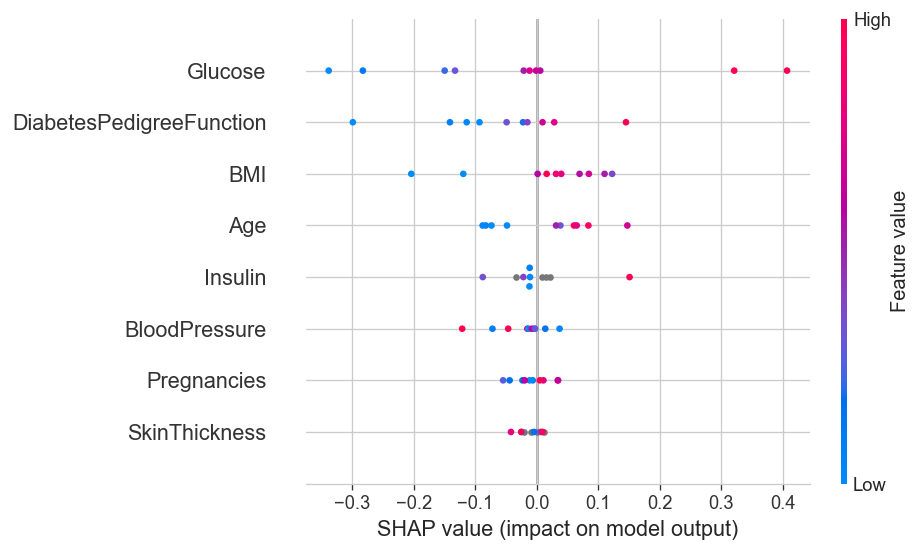

In [34]:
import shap


X_cols = train_data.drop(columns=['Outcome']).columns
def predict_proba_wrapper(numpy_array):
    df = pd.DataFrame(numpy_array, columns=X_cols)
    return predictor.predict_proba(df).iloc[:, 1].values

# 3. Use the features only (Drop 'Outcome') for the explainer
# We use .values to keep SHAP in its preferred format
background_data = train_data.drop(columns=['Outcome']).sample(50)
test_sample = test_data.drop(columns=['Outcome']).sample(10)

explainer = shap.KernelExplainer(predict_proba_wrapper, background_data)
shap_values = explainer.shap_values(test_sample)

shap.summary_plot(shap_values, test_sample)

## Save Artifacts for the Streamlit App
Save all artefacts the Streamlit app needs: predictor path, threshold, feature list,
leaderboard CSV, computed metrics, and SHAP explainer.

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE ARTIFACTS FOR STREAMLIT APP
# ══════════════════════════════════════════════════════════════════════════════

FEAT_COLS = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
             'Insulin','BMI','DiabetesPedigreeFunction','Age']

# -- Threshold (already defined in cell 19 as `threshold`) --------------------
joblib.dump(threshold, 'models/threshold.pkl')
joblib.dump(FEAT_COLS, 'models/feature_cols.pkl')

# -- Leaderboard CSV (all AutoGluon models) -----------------------------------
lb = predictor.leaderboard(
    test_data,
    extra_metrics=['accuracy','precision','f1','roc_auc'],
    silent=True
)
# Rename to the column names the app table expects
lb_clean = lb[['model','score_test','accuracy','precision','f1','roc_auc']].copy()
lb_clean.columns = ['Model','Recall','Accuracy','Precision','F1-Score','AUC-ROC']
lb_clean = lb_clean.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
lb_clean.to_csv('models/model_leaderboard.csv', index=False)
print('Leaderboard saved:')
print(lb_clean.to_string(index=False))

# -- Metrics for the chosen specific_model ------------------------------------
y_true   = test_data['Outcome']
probs_bm = predictor.predict_proba(test_data, model=specific_model).iloc[:, 1]
preds_bm = (probs_bm >= threshold).astype(int)

meta = {
    'best_model':      specific_model,
    'predictor_path':  'AutogluonModels/ag_model',
    'threshold':       float(threshold),
    'features':        FEAT_COLS,
    'eval_metric':     'recall',
    'presets':         'best_quality',
    'test_auc':        round(float(roc_auc_score(y_true, probs_bm)), 4),
    'test_f1':         round(float(f1_score(y_true, preds_bm)), 4),
    'test_recall':     round(float(recall_score(y_true, preds_bm)), 4),
    'test_accuracy':   round(float(accuracy_score(y_true, preds_bm)), 4),
    'test_precision':  round(float(precision_score(y_true, preds_bm)), 4),
}
with open('models/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('\nmetadata.json saved.')

# -- SHAP KernelExplainer (wraps AutoGluon predict_proba) ---------------------
try:
    import shap
    X_cols = train_data.drop(columns=['Outcome']).columns.tolist()

    def _ag_predict(numpy_array):
        df = pd.DataFrame(numpy_array, columns=X_cols)
        return predictor.predict_proba(df, model=specific_model).iloc[:, 1].values

    background      = shap.kmeans(train_data.drop(columns=['Outcome']).values.astype(float), 50)
    shap_explainer  = shap.KernelExplainer(_ag_predict, background)
    joblib.dump(shap_explainer, 'models/shap_explainer.pkl')
    print('SHAP explainer saved.')
except Exception as e:
    print(f'SHAP save skipped: {e}')

# -- Summary ------------------------------------------------------------------
print(f'\n{"="*55}')
print('  ARTIFACT SAVE SUMMARY')
print(f'{"="*55}')
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    print(f'  {fname:<38} {size:>10,} bytes')
print(f'\n  Best Model  : {specific_model}')
print(f'  Threshold   : {threshold}')
print(f'  AUC-ROC     : {meta["test_auc"]:.4f}')
print(f'  Recall      : {meta["test_recall"]:.4f}')
print(f'  F1-Score    : {meta["test_f1"]:.4f}')
print(f'{"="*55}')


Leaderboard saved:
                      Model   Recall  Accuracy  Precision  F1-Score  AUC-ROC
       ExtraTrees_r4_BAG_L1 0.612903  0.811688   0.721519  0.662791 0.878270
        CatBoost_r70_BAG_L1 0.591398  0.782468   0.654762  0.621469 0.865466
         CatBoost_r9_BAG_L1 0.602151  0.788961   0.666667  0.632768 0.864116
       CatBoost_r180_BAG_L1 0.612903  0.788961   0.662791  0.636872 0.863466
       LightGBM_r196_BAG_L1 0.677419  0.788961   0.642857  0.659686 0.863416
        CatBoost_r13_BAG_L1 0.645161  0.798701   0.674157  0.659341 0.862616
       CatBoost_r128_BAG_L1 0.602151  0.779221   0.643678  0.622222 0.862566
     ExtraTrees_r178_BAG_L1 0.612903  0.798701   0.686747  0.647727 0.862366
     ExtraTrees_r172_BAG_L1 0.645161  0.811688   0.705882  0.674157 0.861915
    RandomForest_r34_BAG_L1 0.623656  0.792208   0.666667  0.644444 0.861065
        CatBoost_r12_BAG_L1 0.645161  0.795455   0.666667  0.655738 0.860715
  NeuralNetFastAI_r4_BAG_L1 0.817204  0.782468   0.603175

In [36]:
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference
from sklearn.metrics import accuracy_score

# Derive X_test / y_test from test_data (the notebook's test split)
X_test_fair = test_data.drop(columns=['Outcome'])
y_test_fair  = test_data['Outcome']

# Create a binary 'Senior' flag for the fairness audit (Age > 50 = Senior)
is_senior = X_test_fair['Age'] > 50

# Analyze accuracy and selection rate across age groups
fair_metrics = {
    'accuracy':       accuracy_score,
    'selection_rate': selection_rate
}

mf = MetricFrame(
    metrics=fair_metrics,
    y_true=y_test_fair,
    y_pred=predictor.predict(X_test_fair),
    sensitive_features=is_senior
)

print("Fairness Audit — Performance by Age Group (Senior = Age > 50):")
print(mf.by_group)
print(f"\nDemographic Parity Difference: {demographic_parity_difference(y_test_fair, predictor.predict(X_test_fair), sensitive_features=is_senior):.4f}")


Fairness Audit — Performance by Age Group (Senior = Age > 50):
       accuracy  selection_rate
Age                            
False  0.798535        0.289377
True   0.600000        0.371429

Demographic Parity Difference: 0.0821


In [40]:
# 1. Prepare groups
# Favorable outcome is 0 (No Diabetes)
df_fair = train_data.copy()
df_fair['is_privileged'] = (df_fair['Age'] >= 50).astype(int)

# 2. Calculate Selection Rates (Probability of Outcome == 0)
priv_group = df_fair[df_fair['is_privileged'] == 1]
unpriv_group = df_fair[df_fair['is_privileged'] == 0]

sr_priv = (priv_group['Outcome'] == 0).mean()
sr_unpriv = (unpriv_group['Outcome'] == 0).mean()

# 3. Compute Metrics
disparate_impact = sr_unpriv / sr_priv
stat_parity_diff = sr_unpriv - sr_priv

print(f"Original Disparate Impact: {disparate_impact:.4f}")
print(f"Original Statistical Parity Difference: {stat_parity_diff:.4f}")

Original Disparate Impact: 1.2662
Original Statistical Parity Difference: 0.1309


In [41]:
def calculate_weights(df, protected_col, target_col):
    n = len(df)
    # Total counts for groups and outcomes
    n_p1 = len(df[df[protected_col] == 1]) # Privileged
    n_p0 = len(df[df[protected_col] == 0]) # Unprivileged
    n_f0 = len(df[df[target_col] == 0])    # Favorable
    n_f1 = len(df[df[target_col] == 1])    # Unfavorable
    
    weights = np.ones(n)
    
    # Calculate weights for the 4 combinations
    for p_val in [0, 1]:
        for f_val in [0, 1]:
            # Count observed (n_group_outcome)
            n_group = n_p1 if p_val == 1 else n_p0
            n_fav = n_f0 if f_val == 0 else n_f1
            n_observed = len(df[(df[protected_col] == p_val) & (df[target_col] == f_val)])
            
            # Expected count if there was no bias: (n_group * n_fav) / n
            weight = (n_group * n_fav) / (n * n_observed)
            
            # Apply weight to the slice
            weights[(df[protected_col] == p_val) & (df[target_col] == f_val)] = weight
            
    return weights

# Apply the weights to your train_data
train_data['weights'] = calculate_weights(df_fair, 'is_privileged', 'Outcome')
print("Manual Reweighing weights calculated successfully.")

Manual Reweighing weights calculated successfully.


In [43]:
def check_fairness(data, preds, protected_col='is_privileged', target_col='Outcome'):
    # Create a temporary copy to avoid modifying original data
    df_results = data.copy()
    df_results['preds'] = preds
    
    # Selection Rate for Privileged (p1)
    p1_data = df_results[df_results[protected_col] == 1]
    sr_p1 = len(p1_data[p1_data['preds'] == 1]) / len(p1_data)
    
    # Selection Rate for Unprivileged (p0)
    p0_data = df_results[df_results[protected_col] == 0]
    sr_p0 = len(p0_data[p0_data['preds'] == 1]) / len(p0_data)
    
    # Calculate Metrics
    di = sr_p0 / sr_p1 if sr_p1 > 0 else 0
    spd = sr_p1 - sr_p0
    
    print(f"--- Fairness Metrics for Predictions ---")
    print(f"Selection Rate (Privileged):   {sr_p1:.4f}")
    print(f"Selection Rate (Unprivileged): {sr_p0:.4f}")
    print(f"Disparate Impact:              {di:.4f}")
    print(f"Statistical Parity Difference: {spd:.4f}")
    
    return di, spd

In [ ]:
# # 1. Get predictions from your weighted model
# predictions = predictor.predict(test_data)

# # 2. Re-run your fairness metrics on these predictions
# # (Assuming you have a function called 'check_fairness')
# check_fairness(test_data, predictions)

test_data_fair = test_data.copy()
test_data_fair['is_privileged'] = (test_data_fair['Age'] >= 50).astype(int)

predictions = predictor.predict(test_data)

print("--- Post-Reweighing Fairness Audit (Standard Model on Test Set) ---")
check_fairness(test_data_fair, predictions)

--- Post-Reweighing Fairness Audit (Standard Model on Test Set) ---
--- Fairness Metrics for Predictions ---
Selection Rate (Privileged):   0.4146
Selection Rate (Unprivileged): 0.2809
Disparate Impact:              0.6775
Statistical Parity Difference: 0.1337


(0.6774619960343689, 0.133735269936969)